## Pipeline dựa trên eda mới


In [1]:
import numpy as np
import pandas as pd
import lightgbm as lgb
from lightgbm import LGBMClassifier
import matplotlib.pyplot as plt
import os
import gc
import warnings
import seaborn as sns
from sklearn.linear_model import LogisticRegression
warnings.filterwarnings('ignore')

In [2]:
for dirname, _, filenames in os.walk("Dataset"):
    for filename in filenames:
        print(os.path.join(dirname, filename))

Dataset\sample_submission.csv
Dataset\test_identity.csv
Dataset\test_transaction.csv
Dataset\train_identity.csv
Dataset\train_transaction.csv


In [3]:
train_identity = pd.read_csv("Dataset/train_identity.csv")
train_transaction = pd.read_csv("Dataset/train_transaction.csv")

print(f"train_identity.shape= {train_identity.shape}")
print(f"train_transaction.shape= {train_transaction.shape}")

train_identity.shape= (144233, 41)
train_transaction.shape= (590540, 394)


In [4]:
train = train_transaction.merge(train_identity, how="left", on="TransactionID")
train.head(5)

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,...,samsung browser 6.2,32.0,2220x1080,match_status:2,T,F,T,T,mobile,SAMSUNG SM-G892A Build/NRD90M


In [5]:
del train_identity
del train_transaction
gc.collect()

32

In [6]:
# selected feature: thu thập các feature trích xuất
selected_feature = []

- Biến transactionDT đã được khám phá là thời gian trôi qua kể từ một mốc nào đó và được tính bằng giây
- Theo phân tích tỉ lệ Fraud tăng đột biến ở 1 vài khung giờ cố định trong ngày hơn là số ngày trong tuần nên ta giữ lại đặc trưng `Hours`
- Đặc trưng D9 cũng là `Hour of Day`, nhưng đặc trưng này có quá nhiều giá trị missing và trùng ý nghĩa với cột `Hours` được trích từ TransactionDT nên ta sẽ drop cột `D9`

In [7]:
train['Hour'] = np.floor((train['TransactionDT'] / 3600) % 24)

selected_feature.append('Hour')

- Biến ProductCD cho thấy tỉ lệ giao dịch Fraud chiếm phần lớn ở các mã sản phẩm ít được giao dịch
- Tỉ lệ giao dịch gian lận cũng liên quan đến phân phối thống kê của số tiền giao dịch với các sản phẩm, cụ thể: các nhóm sản phẩm W, R, và H có số tiền được thực hiện ở các giao dịch lừa đảo cao hơn bình thường. Trong khi với nhóm S và C thì lại có tỉ lệ gần bằng

In [8]:
temp_mean = train.groupby('ProductCD')['TransactionAmt'].transform('mean')
temp_std = train.groupby('ProductCD')['TransactionAmt'].transform('std')

# Đánh dấu nguy cơ của các giao dịch theo loại sản phẩm Low - Medium
map_productCD_to_risk = {
    "C": "High",
    "R": "Medium",
    "S": "Medium",
    "H": "Medium",
    "W": "Low"
}
train['ProductCD_Risk'] = train['ProductCD'].map(map_productCD_to_risk)

# Tỷ lệ giữa số tiền giao dịch và mức trung bình của nhóm
train['Amt_to_Mean_ProductCD'] = train['TransactionAmt'] / temp_mean

# Số tiền này cách mức trung bình bao nhiêu lần độ lệch chuẩn?
train['Amt_to_Std_ProductCD'] = (train['TransactionAmt'] - temp_mean) / temp_std

selected_feature.extend(['ProductCD_Risk', 'Amt_to_Mean_ProductCD', 'Amt_to_Std_ProductCD'])

- Tại giá trị của các card1, card2, card3 và card5: có một sự biến động bất thường của các giá trị cụ thể.
- Tỉ lệ gian lận là khá thấp đối với các giá trị phổ biến và ngược lại

In [9]:
# frequent encoding do tỉ lệ gian lận liên quan đến độ phổ biến
card_cols = ['card1', 'card2', 'card3', 'card5']
for col in card_cols:
    fraud_rate_by_col = train.groupby(col)['isFraud'].mean()
    mean_fraud_rate_by_col = fraud_rate_by_col.mean()
    std_fraud_rate_by_col = fraud_rate_by_col.std()

    def risk_level(x):
        if x > mean_fraud_rate_by_col + 2 * std_fraud_rate_by_col:
            return 'high'
        elif x > mean_fraud_rate_by_col + std_fraud_rate_by_col:
            return 'medium'
        else:
            return 'low'
        
    map_risk = fraud_rate_by_col.apply(risk_level)
    train[f'{col}_risk'] = train[col].map(map_risk)

    freq_encoding = train[col].fillna(-999).value_counts().to_dict()
    train[f'{col}_freq'] = train[col].fillna(-999).map(freq_encoding)
    selected_feature.extend([f'{col}_risk', f'{col}_freq'])


- Thẻ card4 có số lượng giao dịch bất thường khá lớn đối với thẻ discover, và lượng tiền được thực hiện trong các giao dịch lừa đảo với loại thẻ này cũng rất lớn.
- -> thêm feature chên lệch số tiền giao dịch hiện tại so với trung bình giao dịch của nhóm thẻ card4

In [10]:
train['card4_Amt_mean'] = train.groupby('card4')['TransactionAmt'].transform("mean")
train['card4_Amt_diff'] = train['TransactionAmt'] - train['card4_Amt_mean']


selected_feature.extend(['card4_Amt_mean', 'card4_Amt_diff'])


- Cột `card6` **Credit** có số lượng giao dịch gian lận lớn hơn hẳn các cột khác -> chuyển cột này thành dữ liệu rời rạc ghi nhận alert

In [11]:
# card6 có điểm alert đáng chú ý ở credit nhưng thông tin về số tiền giao dịch không có nhiều giá trị
train['card6_Credit'] = (train['card6'] == "credit").astype(int)
selected_feature.append('card6_Credit')

- Biến `addr1` có tỉ lệ gian lận cao hơn missing value
- Biến `addr2` có giá trị 65 chiếm tỉ lệ fraud lên tới 55% mặc dù giá trị giao dịch không quá lớn

In [12]:
freq_map = train['addr2'].value_counts(normalize=True)
train['addr2_freq'] = train['addr2'].map(freq_map)

freq_map = train['addr1'].value_counts(normalize=True)
train['addr1_freq'] = train['addr1'].map(freq_map)

# Ta thêm cả biến addr1 vì giá trị null của nó có liên quan đến gian lận
selected_feature.extend(['addr1', 'addr2', 'addr2_freq', 'addr1_freq'])

- Một số domain email có tỉ lệ gian lận cao. Đáng chủ ý là missing data cchieems gần 80& nhưng tỉ lệ gian lận thấp -> ta nên ánh xạ các các domain thành Risk Binning: Low - Medium - High Risk

In [13]:
high_risk_emails = ['protonmail.com', 'mail.com']
medium_risk_emails = ['gmail.com', 'yahoo.com', 'hotmail.com']

def map_email_risk(email):
    if pd.isna(email):
        return 'Low' # 80% null có tỷ lệ gian lận thấp
    elif email in high_risk_emails:
        return 'High'
    elif email in medium_risk_emails:
        return 'Medium'
    else:
        return 'Low'
        
train['Email_Risk_Bin'] = train['P_emaildomain'].apply(map_email_risk)
selected_feature.append('Email_Risk_Bin')

In [14]:
freq_map = train['P_emaildomain'].value_counts(normalize=True)
train['P_email_freq'] = train['P_emaildomain'].map(freq_map)
selected_feature.append('P_email_freq')

In [15]:
freq_map = train['R_emaildomain'].value_counts(normalize=True)
train['R_email_freq'] = train['R_emaildomain'].map(freq_map)
selected_feature.append('R_email_freq')

In [16]:
train['day'] = train['TransactionDT'] // (60*60*24)

first_day = (train['day'] - train['D1']).fillna(-1).astype(int)

train['uid'] = (
    train['card1'].astype(str) + '_' +
    train['addr1'].astype(str) + '_' +
    train['P_emaildomain'].astype(str) + '_' +
    first_day.astype(str)
)

In [17]:
selected_feature.append('uid')

In [18]:
# Tính số tiền trung bình và độ lệch chuẩn của mỗi UID
train['TransactionAmt_mean_uid'] = train.groupby('uid')['TransactionAmt'].transform('mean')
train['TransactionAmt_std_uid'] = train.groupby('uid')['TransactionAmt'].transform('std')

train['TransactionAmt_ratio_uid'] = train['TransactionAmt'] / train['TransactionAmt_mean_uid']

# Tính độ lệch giữa giao dịch hiện tại và trung bình của UID đó
train['TransactionAmt_diff_uid'] = train['TransactionAmt'] - train['TransactionAmt_mean_uid']

train['TransactionAmt_zscore_uid'] = (
    (train['TransactionAmt'] - train['TransactionAmt_mean_uid']) /
    train['TransactionAmt_std_uid']
)
train['cent']=(train['TransactionAmt'] - np.floor(train['TransactionAmt'])).astype('float32')
# Đếm số lượng giao dịch của UID này (Frequency Encoding cho UID)
train['uid_count'] = train.groupby('uid')['TransactionID'].transform('count')
selected_feature.extend([
    'TransactionAmt_mean_uid',
    'TransactionAmt_std_uid',
    'TransactionAmt_ratio_uid',
    'TransactionAmt_diff_uid',
    'TransactionAmt_zscore_uid',
    'uid_count',
    'cent'
])

- giá trị giao dịch của `DeviceType` Mobile là thấp nhất nhưng tỉ lệ gian lận là cao nhất (> 10%)

In [19]:
def map_device_type_risk(type):
    if pd.isna(type):
        return 'Low'
    elif type == "desktop":
        return 'Medium'
    elif type == "mobile":
        return 'High'
    
train['Device_type_risk'] = train['DeviceType'].apply(map_device_type_risk)
selected_feature.append('Device_type_risk')


- Đối với `DeviceInfo`, các dòng máy Android đời cũ (SM-Gxxx...) có tỷ lệ gian lận cao. đặc biệt là rv::11 thường nhắm vào các khoản tiền lớn

- Có thể tạo biến: TransactionAmt / Mean_Amount_by_Device. Nếu một thiết bị ít xuất hiện nhưng thực hiện giao dịch lớn bất thường thì đó là dấu hiệu gian lận.

In [20]:
# TransactionAmt / Mean_Amount_by_Device
train['Device_Amt_Mean'] = train.groupby('DeviceInfo')['TransactionAmt'].transform('mean')
train['Amt_to_Device_Mean_Ratio'] = train['TransactionAmt'] / train['Device_Amt_Mean']

# Flag các dòng máy rủi ro
train['is_old_android'] = train['DeviceInfo'].str.contains('SM-G', na=False, case=False).astype(int)
train['is_rv11'] = train['DeviceInfo'].str.contains('rv:11', na=False, case=False).astype(int)
selected_feature.extend(['Amt_to_Device_Mean_Ratio', 'is_old_android', 'is_rv11'])


- Chú ý một vài feature `id` (ví dụ 13, 14, 18, 21, 22, 24) có một số phân loại có Fraud Rate đỉnh nóc. Có thể chú ý các giá trị và tạo thêm feature High Risk.... ? 

In [21]:
id_cols = ['id_12', 'id_13', 'id_14', 'id_15', 'id_16', 'id_18', 'id_19', 'id_20', 'id_21', 'id_22', 'id_24']

for col in id_cols:
    freq_map = train[col].value_counts(normalize=True)
    train[f'{col}_freq'] = train[col].map(freq_map)
    selected_feature.append(f'{col}_freq')


In [22]:
print(f"Danh sách các categorical feature trích xuất được: {selected_feature}")
print(f"Số các categorical feature trích xuất được: {len(selected_feature)}")

Danh sách các categorical feature trích xuất được: ['Hour', 'ProductCD_Risk', 'Amt_to_Mean_ProductCD', 'Amt_to_Std_ProductCD', 'card1_risk', 'card1_freq', 'card2_risk', 'card2_freq', 'card3_risk', 'card3_freq', 'card5_risk', 'card5_freq', 'card4_Amt_mean', 'card4_Amt_diff', 'card6_Credit', 'addr1', 'addr2', 'addr2_freq', 'addr1_freq', 'Email_Risk_Bin', 'P_email_freq', 'R_email_freq', 'uid', 'TransactionAmt_mean_uid', 'TransactionAmt_std_uid', 'TransactionAmt_ratio_uid', 'TransactionAmt_diff_uid', 'TransactionAmt_zscore_uid', 'uid_count', 'cent', 'Device_type_risk', 'Amt_to_Device_Mean_Ratio', 'is_old_android', 'is_rv11', 'id_12_freq', 'id_13_freq', 'id_14_freq', 'id_15_freq', 'id_16_freq', 'id_18_freq', 'id_19_freq', 'id_20_freq', 'id_21_freq', 'id_22_freq', 'id_24_freq']
Số các categorical feature trích xuất được: 45


In [23]:
M_cols = [M for M in train.columns if M.startswith('M')]
print(f"Các feature bắt đầu bằng M: {M_cols}")

Các feature bắt đầu bằng M: ['M1', 'M2', 'M3', 'M4', 'M5', 'M6', 'M7', 'M8', 'M9']


In [24]:
selected_feature+=M_cols

In [25]:
len(selected_feature)

54

In [26]:
print(f"Danh sách các feature đã chọn: {selected_feature}")

Danh sách các feature đã chọn: ['Hour', 'ProductCD_Risk', 'Amt_to_Mean_ProductCD', 'Amt_to_Std_ProductCD', 'card1_risk', 'card1_freq', 'card2_risk', 'card2_freq', 'card3_risk', 'card3_freq', 'card5_risk', 'card5_freq', 'card4_Amt_mean', 'card4_Amt_diff', 'card6_Credit', 'addr1', 'addr2', 'addr2_freq', 'addr1_freq', 'Email_Risk_Bin', 'P_email_freq', 'R_email_freq', 'uid', 'TransactionAmt_mean_uid', 'TransactionAmt_std_uid', 'TransactionAmt_ratio_uid', 'TransactionAmt_diff_uid', 'TransactionAmt_zscore_uid', 'uid_count', 'cent', 'Device_type_risk', 'Amt_to_Device_Mean_Ratio', 'is_old_android', 'is_rv11', 'id_12_freq', 'id_13_freq', 'id_14_freq', 'id_15_freq', 'id_16_freq', 'id_18_freq', 'id_19_freq', 'id_20_freq', 'id_21_freq', 'id_22_freq', 'id_24_freq', 'M1', 'M2', 'M3', 'M4', 'M5', 'M6', 'M7', 'M8', 'M9']


In [27]:
for i in range(1,16):
    if i in [1,2,3,5,9]: continue
    train['D'+str(i)] =  train['D'+str(i)] - train.TransactionDT/np.float32(24*60*60)
    selected_feature.append('D'+str(i))

In [28]:
C_Cols= [C for C in train.columns if C.startswith('C')]
print(f"Các feature bắt đầu bằng C: {C_Cols}")

Các feature bắt đầu bằng C: ['C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7', 'C8', 'C9', 'C10', 'C11', 'C12', 'C13', 'C14']


In [29]:
selected_feature+=C_Cols

- Ta thêm một số phép encode có liên quan để tăng đặc trưng nhận diện cho model

## Tiếp tục xử lý num feature

In [30]:
num_feature = []
for col in train.columns:
    if (train[col].dtype != "object") and (col not in selected_feature):
        num_feature.append(col)
print(f"Danh sách các num feature trong tập train: {num_feature}")
print(f"Tổng số các num feature trong tập train: {len(num_feature)}")

Danh sách các num feature trong tập train: ['TransactionID', 'isFraud', 'TransactionDT', 'TransactionAmt', 'card1', 'card2', 'card3', 'card5', 'dist1', 'dist2', 'D1', 'D2', 'D3', 'D5', 'D9', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'V29', 'V30', 'V31', 'V32', 'V33', 'V34', 'V35', 'V36', 'V37', 'V38', 'V39', 'V40', 'V41', 'V42', 'V43', 'V44', 'V45', 'V46', 'V47', 'V48', 'V49', 'V50', 'V51', 'V52', 'V53', 'V54', 'V55', 'V56', 'V57', 'V58', 'V59', 'V60', 'V61', 'V62', 'V63', 'V64', 'V65', 'V66', 'V67', 'V68', 'V69', 'V70', 'V71', 'V72', 'V73', 'V74', 'V75', 'V76', 'V77', 'V78', 'V79', 'V80', 'V81', 'V82', 'V83', 'V84', 'V85', 'V86', 'V87', 'V88', 'V89', 'V90', 'V91', 'V92', 'V93', 'V94', 'V95', 'V96', 'V97', 'V98', 'V99', 'V100', 'V101', 'V102', 'V103', 'V104', 'V105', 'V106', 'V107', 'V108', 'V109', 'V110', 'V111', 'V112', 'V113', 'V114', 'V115

In [31]:

V_cols = ['V258', 'V70', 'V283', 'V79', 'V307', 'V312', 'V44', 'V285', 'V293', 'V310', 'V87', 'V158', 'V187', 'V201', 'V49', 'V67', 'V315', 'V127', 'V83', 'V130', 'V314', 'V171', 'V20', 'V159', 'V76', 'V13', 'V129', 'V320', 'V54', 'V282', 'V131', 'V62', 'V139', 'V268', 'V36', 'V56', 'V82', 'V38', 'V99', 'V58', 'V281', 'V332', 'V30', 'V291', 'V136', 'V274', 'V309', 'V78', 'V61', 'V165', 'V311', 'V289', 'V152', 'V160', 'V207', 'V189', 'V52', 'V91', 'V296', 'V81', 'V124', 'V265', 'V11', 'V24', 'V221', 'V257', 'V37', 'V74', 'V55', 'V319', 'V209', 'V271', 'V77', 'V47', 'V244', 'V266', 'V338', 'V155', 'V23', 'V4', 'V26', 'V86', 'V261', 'V203', 'V170', 'V135', 'V287', 'V3', 'V164', 'V267', 'V226', 'V303', 'V206', 'V60', 'V147', 'V40', 'V66', 'V264', 'V256', 'V7', 'V277', 'V109', 'V288', 'V115', 'V215', 'V166', 'V208', 'V6', 'V234', 'V224', 'V43', 'V202', 'V301', 'V106', 'V210', 'V298', 'V46', 'V2', 'V239', 'V216', 'V335', 'V25', 'V290', 'V85', 'V125', 'V205', 'V276', 'V169', 'V18', 'V8', 'V16', 'V262', 'V9', 'V220', 'V63', 'V337', 'V100', 'V50', 'V245', 'V326', 'V275', 'V230', 'V180', 'V162', 'V161', 'V229', 'V174', 'V116', 'V260', 'V123', 'V228', 'V175', 'V183', 'V172', 'V111', 'V176', 'V254', 'V112', 'V334', 'V199', 'V92', 'V108', 'V284', 'V138', 'V223', 'V114', 'V186', 'V250', 'V122', 'V121', 'V27', 'V184', 'V235', 'V89', 'V120']

In [32]:
print(f"Các feature: {selected_feature}")

Các feature: ['Hour', 'ProductCD_Risk', 'Amt_to_Mean_ProductCD', 'Amt_to_Std_ProductCD', 'card1_risk', 'card1_freq', 'card2_risk', 'card2_freq', 'card3_risk', 'card3_freq', 'card5_risk', 'card5_freq', 'card4_Amt_mean', 'card4_Amt_diff', 'card6_Credit', 'addr1', 'addr2', 'addr2_freq', 'addr1_freq', 'Email_Risk_Bin', 'P_email_freq', 'R_email_freq', 'uid', 'TransactionAmt_mean_uid', 'TransactionAmt_std_uid', 'TransactionAmt_ratio_uid', 'TransactionAmt_diff_uid', 'TransactionAmt_zscore_uid', 'uid_count', 'cent', 'Device_type_risk', 'Amt_to_Device_Mean_Ratio', 'is_old_android', 'is_rv11', 'id_12_freq', 'id_13_freq', 'id_14_freq', 'id_15_freq', 'id_16_freq', 'id_18_freq', 'id_19_freq', 'id_20_freq', 'id_21_freq', 'id_22_freq', 'id_24_freq', 'M1', 'M2', 'M3', 'M4', 'M5', 'M6', 'M7', 'M8', 'M9', 'D4', 'D6', 'D7', 'D8', 'D10', 'D11', 'D12', 'D13', 'D14', 'D15', 'C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7', 'C8', 'C9', 'C10', 'C11', 'C12', 'C13', 'C14']


In [33]:
selected_feature+=V_cols

In [34]:
selected_feature.append('isFraud')

In [35]:
id_cols = [col for col in train.columns if col.startswith('id_')]
print(f"Các feature bắt đầu bằng id_: {id_cols}")

Các feature bắt đầu bằng id_: ['id_01', 'id_02', 'id_03', 'id_04', 'id_05', 'id_06', 'id_07', 'id_08', 'id_09', 'id_10', 'id_11', 'id_12', 'id_13', 'id_14', 'id_15', 'id_16', 'id_17', 'id_18', 'id_19', 'id_20', 'id_21', 'id_22', 'id_23', 'id_24', 'id_25', 'id_26', 'id_27', 'id_28', 'id_29', 'id_30', 'id_31', 'id_32', 'id_33', 'id_34', 'id_35', 'id_36', 'id_37', 'id_38', 'id_12_freq', 'id_13_freq', 'id_14_freq', 'id_15_freq', 'id_16_freq', 'id_18_freq', 'id_19_freq', 'id_20_freq', 'id_21_freq', 'id_22_freq', 'id_24_freq']


In [36]:
train.head()

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,id_13_freq,id_14_freq,id_15_freq,id_16_freq,id_18_freq,id_19_freq,id_20_freq,id_21_freq,id_22_freq,id_24_freq
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,...,NaN,0.161049,0.437011,0.487212,NaN,0.036722,0.004847,NaN,NaN,NaN


In [37]:
selected_feature+= id_cols

In [38]:
selected_feature = list(dict.fromkeys(selected_feature))
train = train[selected_feature]

In [39]:
features_drop=['id_14',
 'id_34',
 'M5',
 'id_32',
 'id_33',
 'id_23',
 'id_27',
 'id_22',
 'id_08',
 'id_26',
 'id_21',
 'id_25',
 'id_24',
 'C3',
 'id_07',
 'id_30',
 'card4']

In [40]:
features_drop = set(features_drop)
selected_feature = [x for x in selected_feature if x not in features_drop]

## Chia tập và train model

- Train/Val/Test với tỉ lệ 8/1/1 chia đều phân phối nhãn

In [41]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    balanced_accuracy_score,
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)


from xgboost import XGBClassifier

In [42]:
y = train.pop('isFraud')
X = train

In [43]:
X.head()

,Hour,ProductCD_Risk,Amt_to_Mean_ProductCD,Amt_to_Std_ProductCD,card1_risk,card1_freq,card2_risk,card2_freq,card3_risk,card3_freq,...,id_29,id_30,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38
0,0.0,Low,0.447249,-0.315028,medium,43,NaN,8933,low,521287,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0.0,Low,0.189346,-0.462013,low,683,low,3056,low,521287,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,0.0,Low,0.385222,-0.350379,low,1108,low,38145,low,521287,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,0.0,Low,0.326459,-0.383869,low,4209,low,6137,low,521287,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0.0,Medium,0.683340,-0.374006,low,18,low,14541,low,521287,...,NotFound,Android 7.0,samsung browser 6.2,32.0,2220x1080,match_status:2,T,F,T,T


In [44]:
import gc
gc.collect()

0

In [45]:
x_train, x_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
x_val, x_test, y_val, y_test = train_test_split(x_val, y_val, test_size=0.5, random_state=42, stratify=y_val)

In [46]:
import pandas as pd

pd.set_option('display.max_columns', None)
x_train.head()

,Hour,ProductCD_Risk,Amt_to_Mean_ProductCD,Amt_to_Std_ProductCD,card1_risk,card1_freq,card2_risk,card2_freq,card3_risk,card3_freq,card5_risk,card5_freq,card4_Amt_mean,card4_Amt_diff,card6_Credit,addr1,addr2,addr2_freq,addr1_freq,Email_Risk_Bin,P_email_freq,R_email_freq,uid,TransactionAmt_mean_uid,TransactionAmt_std_uid,TransactionAmt_ratio_uid,TransactionAmt_diff_uid,TransactionAmt_zscore_uid,uid_count,cent,Device_type_risk,Amt_to_Device_Mean_Ratio,is_old_android,is_rv11,id_12_freq,id_13_freq,id_14_freq,id_15_freq,id_16_freq,id_18_freq,id_19_freq,id_20_freq,id_21_freq,id_22_freq,id_24_freq,M1,M2,M3,M4,M5,M6,M7,M8,M9,D4,D6,D7,D8,D10,D11,D12,D13,D14,D15,C1,C2,C3,C4,C5,C6,C7,C8,C9,C10,C11,C12,C13,C14,V258,V70,V283,V79,V307,V312,V44,V285,V293,V310,V87,V158,V187,V201,V49,V67,V315,V127,V83,V130,V314,V171,V20,V159,V76,V13,V129,V320,V54,V282,V131,V62,V139,V268,V36,V56,V82,V38,V99,V58,V281,V332,V30,V291,V136,V274,V309,V78,V61,V165,V311,V289,V152,V160,V207,V189,V52,V91,V296,V81,V124,V265,V11,V24,V221,V257,V37,V74,V55,V319,V209,V271,V77,V47,V244,V266,V338,V155,V23,V4,V26,V86,V261,V203,V170,V135,V287,V3,V164,V267,V226,V303,V206,V60,V147,V40,V66,V264,V256,V7,V277,V109,V288,V115,V215,V166,V208,V6,V234,V224,V43,V202,V301,V106,V210,V298,V46,V2,V239,V216,V335,V25,V290,V85,V125,V205,V276,V169,V18,V8,V16,V262,V9,V220,V63,V337,V100,V50,V245,V326,V275,V230,V180,V162,V161,V229,V174,V116,V260,V123,V228,V175,V183,V172,V111,V176,V254,V112,V334,V199,V92,V108,V284,V138,V223,V114,V186,V250,V122,V121,V27,V184,V235,V89,V120,id_01,id_02,id_03,id_04,id_05,id_06,id_07,id_08,id_09,id_10,id_11,id_12,id_13,id_14,id_15,id_16,id_17,id_18,id_19,id_20,id_21,id_22,id_23,id_24,id_25,id_26,id_27,id_28,id_29,id_30,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38
40809,16.0,Medium,0.594155,-0.480909,low,16,low,7180,low,521287,low,1338,173.057137,-73.057137,1,264.0,87.0,0.991706,0.075967,Low,0.074580,0.149529,6177_264.0_anonymous.com_-598,100.000000,0.000000,1.000000,0.000000,NaN,2,0.00,Medium,0.829921,0,0,0.85296,0.456323,0.208148,0.480392,0.512788,NaN,0.000086,0.040672,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,597.994337,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0,0.0,2.0,0.0,1.0,0.0,2.0,0.0,2.0,1.0,0.0,2.0,1.0,1.0,NaN,0.0,NaN,0.0,0.0,NaN,0.0,0.0,0.0,NaN,1.0,1.0,0.0,NaN,NaN,0.0,0.0,NaN,0.0,0.0,0.0,NaN,0.0,NaN,NaN,0.0,0.0,NaN,0.0,0.0,NaN,1.0,0.0,NaN,NaN,NaN,NaN,0.0,NaN,0.0,0.0,NaN,1.0,0.0,0.0,0.0,NaN,NaN,0.0,0.0,0.0,1.0,0.0,0.0,0.0,NaN,NaN,0.0,NaN,1.0,0.0,NaN,NaN,1.0,1.0,NaN,NaN,NaN,0.0,0.0,0.0,NaN,NaN,1.0,0.0,0.0,1.0,NaN,NaN,NaN,NaN,1.0,0.0,0.0,0.0,0.0,NaN,0.0,0.0,0.0,1.0,0.0,NaN,0.0,NaN,NaN,0.0,1.0,NaN,0.0,1.0,0.0,1.0,0.0,0.0,0.0,NaN,0.0,0.0,NaN,0.0,0.0,0.0,0.0,0.0,NaN,NaN,0.0,0.0,0.0,NaN,1.0,NaN,1.0,0.0,0.0,0.0,NaN,NaN,NaN,1.0,NaN,0.0,NaN,0.0,0.0,NaN,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,1.0,NaN,1.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,NaN,0.0,0.0,NaN,1.0,-5.0,58410.0,0.0,0.0,0.0,0.0,NaN,NaN,0.0,0.0,100.0,NotFound,52.0,-360.0,Found,Found,166.0,NaN,300.0,214.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Found,Found,Windows 7,ie 11.0 for desktop,24.0,1920x1080,match_status:2,T,F,T,T
285886,2.0,Low,0.195810,-0.458329,low,281,low,346,low,521287,low,81513,132.387731,-102.397731,0,143.0,87.0,0.991706,0.018684,Medium,0.460315,NaN,7900_143.0_gmail.com_81,29.990000,0.000000,1.000000,0.000000,NaN,2,0.99,Low,NaN,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,T,T,T,M0,T,F,F,F,T,-81.113565,NaN,NaN,NaN,-81.113565,-81.113565,NaN,NaN,NaN,-81.113565,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,NaN,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,NaN,NaN,NaN,0.0,1.0,0.0,0.0,1.0,0.0,0.0,NaN,1.0,NaN,1.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0,NaN,NaN,1.0,1.0,1.0,1.0,0.0,0.0,0.0,NaN,0.0,1.0,0.0,NaN,0.0,1.0,1.0,NaN,0.0,0.0,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,1.0,NaN,0.0,1.0,NaN,NaN,1.0,0.0,1.0,0.0,NaN,NaN,1.0,1.0,NaN,NaN,NaN,NaN,1.0,1.0,1.0,1.0,NaN,NaN,NaN,0.0,0.0,1.0,NaN,NaN,NaN,0.0,NaN,0.0,NaN,0.0,1.0,NaN,NaN,1.0,NaN,1.0,0.0,1.0,NaN,NaN,NaN,1.0,NaN,NaN,0.0,NaN,0.0,0.0,Na

In [47]:
# ===== xử lý numeric =====
num_cols = x_train.select_dtypes(include=[np.number]).columns

x_train[num_cols] = x_train[num_cols].fillna(-999)
x_val[num_cols]   = x_val[num_cols].fillna(-999)
x_test[num_cols]  = x_test[num_cols].fillna(-999)

# ===== xử lý categorical =====
cat_cols = x_train.select_dtypes(include=['object']).columns

for col in cat_cols:
    x_train[col] = x_train[col].fillna('missing')
    x_val[col]   = x_val[col].fillna('missing')
    x_test[col]  = x_test[col].fillna('missing')

In [48]:
def clean(df):
    df = df.replace([np.inf, -np.inf], np.nan)
    return df

x_train = clean(x_train)
x_val   = clean(x_val)
x_test  = clean(x_test)

# chỉ check numeric
num_cols = x_train.select_dtypes(include=[np.number])
print(np.isinf(num_cols).sum().sum())

0


In [49]:
# copy ra 2 version
x_train_lgb = x_train.copy()
x_val_lgb   = x_val.copy()
x_test_lgb  = x_test.copy()

x_train_xgb = x_train.copy()
x_val_xgb   = x_val.copy()
x_test_xgb  = x_test.copy()

In [50]:
for col in cat_cols:
    x_train_lgb[col] = x_train_lgb[col].astype('category')
    x_val_lgb[col]   = x_val_lgb[col].astype('category')
    x_test_lgb[col]  = x_test[col].astype('category')

In [51]:
from sklearn.preprocessing import OrdinalEncoder

encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)

x_train_xgb[cat_cols] = encoder.fit_transform(x_train_xgb[cat_cols].astype(str))
x_val_xgb[cat_cols]   = encoder.transform(x_val_xgb[cat_cols].astype(str))
x_test_xgb[cat_cols]  = encoder.transform(x_test_xgb[cat_cols].astype(str))

In [52]:
ratio = float(y_train.value_counts()[0]) / y_train.value_counts()[1]
print(f"ratio= {ratio}")
model_xgb = XGBClassifier(
    n_estimators=2000,        
    learning_rate=0.06,       
    max_depth=8,               
    subsample=0.8,            
    colsample_bytree=0.4, 
    eval_metric='auc',
    tree_method='hist',
    enable_categorical=True,
    scale_pos_weight=ratio,    
    min_child_weight=50,       
    reg_alpha=0.1,             
    reg_lambda=1.0,            
    random_state=42,         
    early_stopping_rounds=50   
)



ratio= 27.580278281911674


In [53]:
model_lgb = LGBMClassifier(
    boosting_type='goss',      
    n_estimators=3000,         
    learning_rate=0.03,        
    num_leaves=64,             
    max_depth=8,               
    
    min_child_samples=20,      
    reg_alpha=0.1,             
    reg_lambda=1.0,            
    
    scale_pos_weight=ratio,
    metric='auc', 
    
    random_state=42,
    n_jobs=-1                  
)

In [54]:

callbacks = [
    lgb.early_stopping(stopping_rounds=50, verbose=True),
    lgb.log_evaluation(period=50)
]
model_lgb.fit(
    x_train_lgb, 
    y_train,
    eval_set=[(x_train_lgb, y_train), (x_val_lgb, y_val)],
    eval_metric='auc',
    categorical_feature=cat_cols.to_list(),       
    callbacks=callbacks
)

[LightGBM] [Warning] Found boosting=goss. For backwards compatibility reasons, LightGBM interprets this as boosting=gbdt, data_sample_strategy=goss.To suppress this warning, set data_sample_strategy=goss instead.
[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
[LightGBM] [Warning] Found boosting=goss. For backwards compatibility reasons, LightGBM interprets this as boosting=gbdt, data_sample_strategy=goss.To suppress this warning, set data_sample_strategy=goss instead.
[LightGBM] [Info] Number of positive: 16530, number of negative: 455902
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.414234 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 40530
[LightGBM]

,boosting_type,'goss'
,num_leaves,64
,max_depth,8
,learning_rate,0.03
,n_estimators,3000
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [55]:
y_val_pred = model_lgb.predict(x_val_lgb)

print(f"classification_report: \n {classification_report(y_val, y_val_pred)}")
cm = confusion_matrix(y_val, y_val_pred)

[LightGBM] [Warning] Found boosting=goss. For backwards compatibility reasons, LightGBM interprets this as boosting=gbdt, data_sample_strategy=goss.To suppress this warning, set data_sample_strategy=goss instead.
classification_report: 
               precision    recall  f1-score   support

           0       0.99      0.99      0.99     56987
           1       0.71      0.86      0.78      2067

    accuracy                           0.98     59054
   macro avg       0.85      0.92      0.89     59054
weighted avg       0.99      0.98      0.98     59054



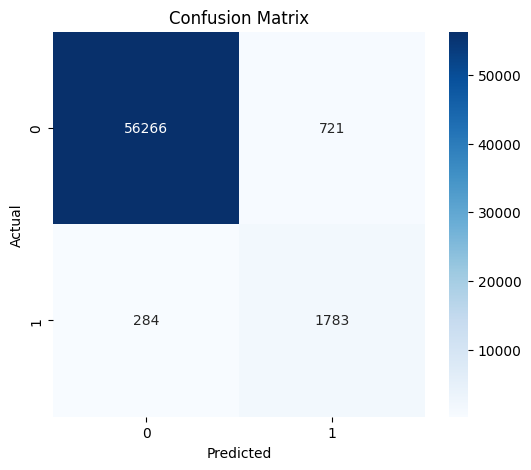

In [56]:
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')

plt.show()

In [57]:
    
model_xgb.fit(
    x_train_xgb,
    y_train,
    eval_set=[(x_train_xgb, y_train),
        (x_val_xgb, y_val)
    ],
)

[0]	validation_0-auc:0.85920	validation_1-auc:0.86154
[1]	validation_0-auc:0.88735	validation_1-auc:0.88615
[2]	validation_0-auc:0.89440	validation_1-auc:0.89099
[3]	validation_0-auc:0.89630	validation_1-auc:0.89281
[4]	validation_0-auc:0.89658	validation_1-auc:0.89313
[5]	validation_0-auc:0.89641	validation_1-auc:0.89378
[6]	validation_0-auc:0.90039	validation_1-auc:0.89957
[7]	validation_0-auc:0.90037	validation_1-auc:0.89954
[8]	validation_0-auc:0.90322	validation_1-auc:0.90269
[9]	validation_0-auc:0.90498	validation_1-auc:0.90475
[10]	validation_0-auc:0.90670	validation_1-auc:0.90594
[11]	validation_0-auc:0.90862	validation_1-auc:0.90835
[12]	validation_0-auc:0.91056	validation_1-auc:0.91041
[13]	validation_0-auc:0.91211	validation_1-auc:0.91221
[14]	validation_0-auc:0.91230	validation_1-auc:0.91266
[15]	validation_0-auc:0.91353	validation_1-auc:0.91411
[16]	validation_0-auc:0.91480	validation_1-auc:0.91547
[17]	validation_0-auc:0.91622	validation_1-auc:0.91682
[18]	validation_0-au

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.4
,device,None
,early_stopping_rounds,50
,enable_categorical,True
,eval_metric,'auc'


In [58]:
y_val_pred = model_xgb.predict(x_val_xgb)

print(f"classification_report: \n {classification_report(y_val, y_val_pred)}")
cm = confusion_matrix(y_val, y_val_pred)

classification_report: 
               precision    recall  f1-score   support

           0       0.99      0.99      0.99     56987
           1       0.72      0.86      0.78      2067

    accuracy                           0.98     59054
   macro avg       0.86      0.92      0.89     59054
weighted avg       0.99      0.98      0.98     59054



In [59]:
import numpy as np
from sklearn.metrics import precision_score, recall_score

# predict proba
lgb_pred = model_lgb.predict_proba(x_val_lgb)[:, 1]
xgb_pred = model_xgb.predict_proba(x_val_xgb)[:, 1]

best_weight = 0
best_recall = 0
best_threshold = 0

for w in np.arange(0, 1.01, 0.05):
    ensemble_pred = w * lgb_pred + (1 - w) * xgb_pred

    # tìm threshold cho mỗi weight
    for thresh in np.arange(0.01, 0.99, 0.01):
        y_pred = (ensemble_pred >= thresh).astype(int)

        precision = precision_score(y_val, y_pred, zero_division=0)
        recall = recall_score(y_val, y_pred)

        if precision >= 0.6:
            if recall > best_recall:
                best_recall = recall
                best_weight = w
                best_threshold = thresh

print("Best weight (LGB):", best_weight)
print("Best weight (XGB):", 1 - best_weight)
print("Best threshold:", best_threshold)
print("Best recall:", best_recall)

[LightGBM] [Warning] Found boosting=goss. For backwards compatibility reasons, LightGBM interprets this as boosting=gbdt, data_sample_strategy=goss.To suppress this warning, set data_sample_strategy=goss instead.
Best weight (LGB): 0.5
Best weight (XGB): 0.5
Best threshold: 0.36000000000000004
Best recall: 0.8988872762457668


In [60]:
ensemble_pred = best_weight * lgb_pred + (1 - best_weight) * xgb_pred
y_final = (ensemble_pred >= best_threshold).astype(int)

In [61]:
from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(y_val, y_final))
print(confusion_matrix(y_val, y_final))

              precision    recall  f1-score   support

           0       1.00      0.98      0.99     56987
           1       0.60      0.90      0.72      2067

    accuracy                           0.98     59054
   macro avg       0.80      0.94      0.86     59054
weighted avg       0.98      0.98      0.98     59054

[[55772  1215]
 [  209  1858]]


In [62]:

print(f"ratio= {ratio}")
model_xgb = XGBClassifier(
    n_estimators=1544,        
    learning_rate=0.06,       
    max_depth=8,               
    subsample=0.8,            
    colsample_bytree=0.4, 
    eval_metric='auc',
    tree_method='hist',
    enable_categorical=True,
    scale_pos_weight=ratio,    
    min_child_weight=50,       
    reg_alpha=0.1,             
    reg_lambda=1.0,            
    random_state=42,         
    #early_stopping_rounds=50   
)



ratio= 27.580278281911674


In [63]:
import pandas as pd

x_full_xgb = pd.concat([x_train_xgb, x_val_xgb])
y_full = pd.concat([y_train, y_val])

# convert categorical
# for col in cat_cols:
#     x_full_xgb[col] = x_full_xgb[col].astype("category")

model_xgb.fit(
    x_full_xgb,
    y_full
)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.4
,device,None
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,'auc'


In [64]:
model_lgb = LGBMClassifier(
    boosting_type='goss',      
    n_estimators=3000,         
    learning_rate=0.03,        
    num_leaves=64,             
    max_depth=8,               
    
    min_child_samples=20,      
    reg_alpha=0.1,             
    reg_lambda=1.0,            
    
    scale_pos_weight=ratio,
    metric='auc', 
    
    random_state=42,
    n_jobs=-1                  
)

In [65]:
import pandas as pd

x_full_lgb = pd.concat([x_train_lgb, x_val_lgb])
y_full = pd.concat([y_train, y_val])

# # convert categorical
for col in cat_cols:
    x_full_lgb[col] = x_full_lgb[col].astype("category")

model_lgb.fit(
    x_full_lgb,
    y_full,
    eval_metric='auc',
    categorical_feature=cat_cols.to_list(),
    callbacks=[lgb.log_evaluation(50)]
)

[LightGBM] [Warning] Found boosting=goss. For backwards compatibility reasons, LightGBM interprets this as boosting=gbdt, data_sample_strategy=goss.To suppress this warning, set data_sample_strategy=goss instead.
[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
[LightGBM] [Warning] Found boosting=goss. For backwards compatibility reasons, LightGBM interprets this as boosting=gbdt, data_sample_strategy=goss.To suppress this warning, set data_sample_strategy=goss instead.
[LightGBM] [Info] Number of positive: 18597, number of negative: 512889
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.391009 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 40529
[LightGBM]

,boosting_type,'goss'
,num_leaves,64
,max_depth,8
,learning_rate,0.03
,n_estimators,3000
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [66]:
# Prepare x_test data for XGBoost (apply same encoding as training data)
x_test_xgb = x_test.copy()
x_test_xgb[cat_cols] = encoder.transform(x_test_xgb[cat_cols].astype(str))

y_test_pred = model_xgb.predict(x_test_xgb)
y_test_score = model_xgb.predict_proba(x_test_xgb)[:, 1]

print(f"classification_report: \n {classification_report(y_test, y_test_pred)}")
print(f"accuracy score: {accuracy_score(y_test, y_test_pred):.4f}")
print(f"balanced accuracy score: {balanced_accuracy_score(y_test, y_test_pred):.4f}")
print(f"roc auc score: {roc_auc_score(y_test, y_test_score):.4f}")
cm_xgb = confusion_matrix(y_test, y_test_pred)

classification_report: 
               precision    recall  f1-score   support

           0       0.99      0.99      0.99     56988
           1       0.71      0.85      0.77      2066

    accuracy                           0.98     59054
   macro avg       0.85      0.92      0.88     59054
weighted avg       0.98      0.98      0.98     59054

accuracy score: 0.9826
balanced accuracy score: 0.9171
roc auc score: 0.9794


In [67]:
# Prepare x_test data for LightGBM (convert categorical columns to category type)
x_test_lgb = x_test.copy()
for col in cat_cols:
    x_test_lgb[col] = x_test_lgb[col].astype("category")

y_test_pred_lgb = model_lgb.predict(x_test_lgb)
y_test_score_lgb = model_lgb.predict_proba(x_test_lgb)[:, 1]

print(f"classification_report: \n {classification_report(y_test, y_test_pred_lgb)}")
print(f"accuracy score: {accuracy_score(y_test, y_test_pred_lgb):.4f}")
print(f"balanced accuracy score: {balanced_accuracy_score(y_test, y_test_pred_lgb):.4f}")
print(f"roc auc score: {roc_auc_score(y_test, y_test_score_lgb):.4f}")
cm_lgb = confusion_matrix(y_test, y_test_pred_lgb)

[LightGBM] [Warning] Found boosting=goss. For backwards compatibility reasons, LightGBM interprets this as boosting=gbdt, data_sample_strategy=goss.To suppress this warning, set data_sample_strategy=goss instead.
[LightGBM] [Warning] Found boosting=goss. For backwards compatibility reasons, LightGBM interprets this as boosting=gbdt, data_sample_strategy=goss.To suppress this warning, set data_sample_strategy=goss instead.
classification_report: 
               precision    recall  f1-score   support

           0       0.99      0.99      0.99     56988
           1       0.70      0.84      0.77      2066

    accuracy                           0.98     59054
   macro avg       0.85      0.91      0.88     59054
weighted avg       0.98      0.98      0.98     59054

accuracy score: 0.9819
balanced accuracy score: 0.9146
roc auc score: 0.9795


In [68]:
# Prepare validation data for both models
x_val_lgb_pred = x_val.copy()
for col in cat_cols:
    x_val_lgb_pred[col] = x_val_lgb_pred[col].astype("category")

x_val_xgb_pred = x_val.copy()
x_val_xgb_pred[cat_cols] = encoder.transform(x_val_xgb_pred[cat_cols].astype(str))

preds_lgb = model_lgb.predict_proba(x_val_lgb_pred)[:, 1]
preds_xgb = model_xgb.predict_proba(x_val_xgb_pred)[:, 1]

X_meta_val = np.column_stack((preds_lgb, preds_xgb))

meta_learner = LogisticRegression(class_weight='balanced', random_state=42)
meta_learner.fit(X_meta_val, y_val)

print("Trọng số học được (Coefficients):")
print(f" - LightGBM: {meta_learner.coef_[0][0]:.4f}")
print(f" - XGBoost: {meta_learner.coef_[0][1]:.4f}")
print(f" - Bias (Intercept): {meta_learner.intercept_[0]:.4f}\n")

[LightGBM] [Warning] Found boosting=goss. For backwards compatibility reasons, LightGBM interprets this as boosting=gbdt, data_sample_strategy=goss.To suppress this warning, set data_sample_strategy=goss instead.
Trọng số học được (Coefficients):
 - LightGBM: 3.7767
 - XGBoost: 12.2993
 - Bias (Intercept): -8.6827



In [69]:
preds_lgb_test = model_lgb.predict_proba(x_test_lgb)[:, 1]
preds_xgb_test = model_xgb.predict_proba(x_test_xgb)[:, 1]

X_meta_test = np.column_stack((preds_lgb_test, preds_xgb_test))

meta_preds_proba_test = meta_learner.predict_proba(X_meta_test)[:, 1]
meta_preds_test = (meta_preds_proba_test >= 0.5).astype(int)

print(f"classification_report: \n {classification_report(y_test, meta_preds_test)}")
print(f"accuracy score: {accuracy_score(y_test, meta_preds_test):.4f}")
print(f"balanced accuracy score: {balanced_accuracy_score(y_test, meta_preds_test):.4f}")
print(f"roc auc score: {roc_auc_score(y_test, meta_preds_proba_test):.4f}")
cm = confusion_matrix(y_test, meta_preds_test)

[LightGBM] [Warning] Found boosting=goss. For backwards compatibility reasons, LightGBM interprets this as boosting=gbdt, data_sample_strategy=goss.To suppress this warning, set data_sample_strategy=goss instead.
classification_report: 
               precision    recall  f1-score   support

           0       0.99      0.99      0.99     56988
           1       0.77      0.84      0.80      2066

    accuracy                           0.99     59054
   macro avg       0.88      0.91      0.90     59054
weighted avg       0.99      0.99      0.99     59054

accuracy score: 0.9854
balanced accuracy score: 0.9148
roc auc score: 0.9809


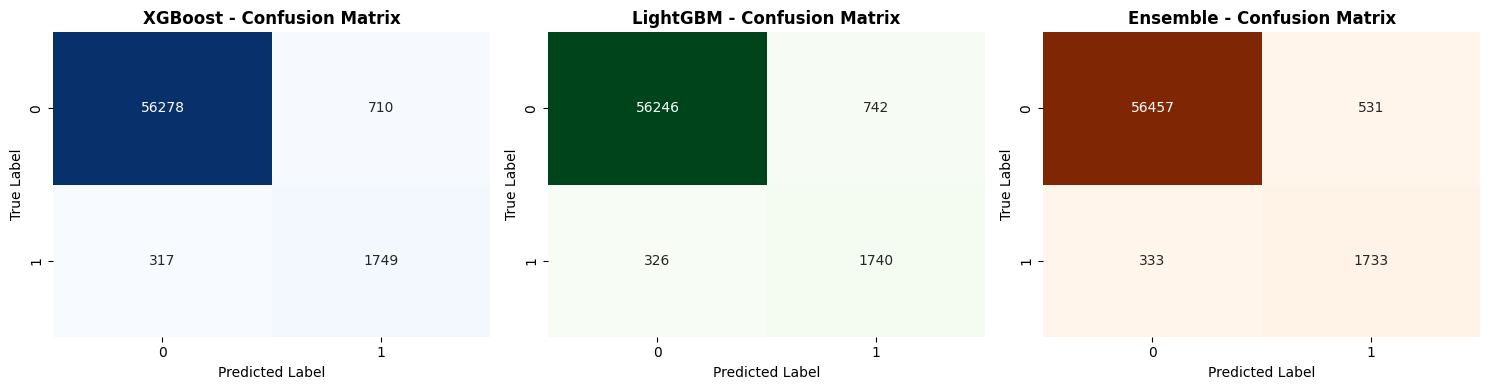

In [70]:
# Visualize confusion matrices for all three models
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Plot XGBoost confusion matrix
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Blues', ax=axes[0], cbar=False)
axes[0].set_title('XGBoost - Confusion Matrix', fontsize=12, fontweight='bold')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

# Plot LightGBM confusion matrix
sns.heatmap(cm_lgb, annot=True, fmt='d', cmap='Greens', ax=axes[1], cbar=False)
axes[1].set_title('LightGBM - Confusion Matrix', fontsize=12, fontweight='bold')
axes[1].set_ylabel('True Label')
axes[1].set_xlabel('Predicted Label')

# Plot Ensemble (Meta-learner) confusion matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', ax=axes[2], cbar=False)
axes[2].set_title('Ensemble - Confusion Matrix', fontsize=12, fontweight='bold')
axes[2].set_ylabel('True Label')
axes[2].set_xlabel('Predicted Label')

plt.tight_layout()
plt.show()

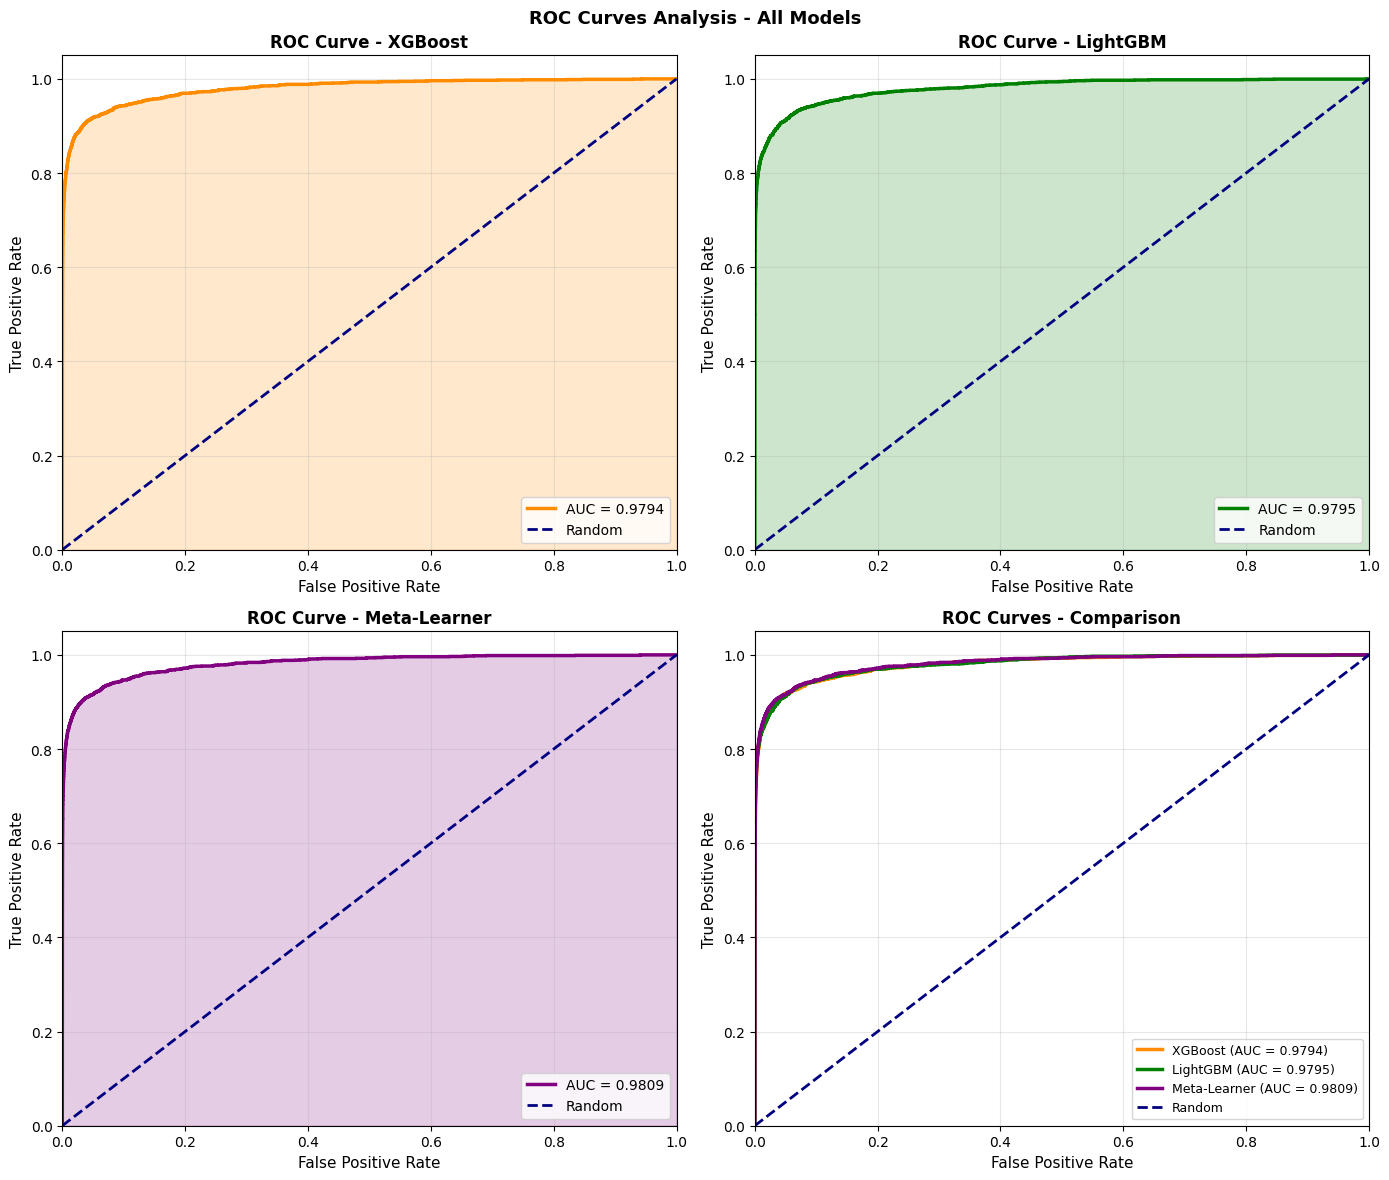

ROC-AUC SCORES SUMMARY
XGBoost        AUC: 0.979371
LightGBM       AUC: 0.979545
Meta-Learner   AUC: 0.980923


In [71]:
from sklearn.metrics import roc_curve, auc
# XGBoost
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, preds_xgb_test)
auc_xgb = auc(fpr_xgb, tpr_xgb)

# LightGBM
fpr_lgb, tpr_lgb, _ = roc_curve(y_test, preds_lgb_test)
auc_lgb = auc(fpr_lgb, tpr_lgb)

# Meta-Learner
fpr_meta, tpr_meta, _ = roc_curve(y_test, meta_preds_proba_test)
auc_meta = auc(fpr_meta, tpr_meta)

# === Vẽ ROC Curves - Layout 2x2 ===
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# XGBoost ROC
axes[0, 0].plot(fpr_xgb, tpr_xgb, color='darkorange', lw=2.5, label=f'AUC = {auc_xgb:.4f}')
axes[0, 0].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random')
axes[0, 0].fill_between(fpr_xgb, tpr_xgb, alpha=0.2, color='darkorange')
axes[0, 0].set_xlim([0.0, 1.0])
axes[0, 0].set_ylim([0.0, 1.05])
axes[0, 0].set_xlabel('False Positive Rate', fontsize=11)
axes[0, 0].set_ylabel('True Positive Rate', fontsize=11)
axes[0, 0].set_title('ROC Curve - XGBoost', fontsize=12, fontweight='bold')
axes[0, 0].legend(loc="lower right", fontsize=10)
axes[0, 0].grid(alpha=0.3)

# LightGBM ROC
axes[0, 1].plot(fpr_lgb, tpr_lgb, color='green', lw=2.5, label=f'AUC = {auc_lgb:.4f}')
axes[0, 1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random')
axes[0, 1].fill_between(fpr_lgb, tpr_lgb, alpha=0.2, color='green')
axes[0, 1].set_xlim([0.0, 1.0])
axes[0, 1].set_ylim([0.0, 1.05])
axes[0, 1].set_xlabel('False Positive Rate', fontsize=11)
axes[0, 1].set_ylabel('True Positive Rate', fontsize=11)
axes[0, 1].set_title('ROC Curve - LightGBM', fontsize=12, fontweight='bold')
axes[0, 1].legend(loc="lower right", fontsize=10)
axes[0, 1].grid(alpha=0.3)

# Meta-Learner ROC
axes[1, 0].plot(fpr_meta, tpr_meta, color='purple', lw=2.5, label=f'AUC = {auc_meta:.4f}')
axes[1, 0].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random')
axes[1, 0].fill_between(fpr_meta, tpr_meta, alpha=0.2, color='purple')
axes[1, 0].set_xlim([0.0, 1.0])
axes[1, 0].set_ylim([0.0, 1.05])
axes[1, 0].set_xlabel('False Positive Rate', fontsize=11)
axes[1, 0].set_ylabel('True Positive Rate', fontsize=11)
axes[1, 0].set_title('ROC Curve - Meta-Learner', fontsize=12, fontweight='bold')
axes[1, 0].legend(loc="lower right", fontsize=10)
axes[1, 0].grid(alpha=0.3)

# Comparison - Tất cả 3 models
axes[1, 1].plot(fpr_xgb, tpr_xgb, color='darkorange', lw=2.5, label=f'XGBoost (AUC = {auc_xgb:.4f})')
axes[1, 1].plot(fpr_lgb, tpr_lgb, color='green', lw=2.5, label=f'LightGBM (AUC = {auc_lgb:.4f})')
axes[1, 1].plot(fpr_meta, tpr_meta, color='purple', lw=2.5, label=f'Meta-Learner (AUC = {auc_meta:.4f})')
axes[1, 1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random')
axes[1, 1].set_xlim([0.0, 1.0])
axes[1, 1].set_ylim([0.0, 1.05])
axes[1, 1].set_xlabel('False Positive Rate', fontsize=11)
axes[1, 1].set_ylabel('True Positive Rate', fontsize=11)
axes[1, 1].set_title('ROC Curves - Comparison', fontsize=12, fontweight='bold')
axes[1, 1].legend(loc="lower right", fontsize=9)
axes[1, 1].grid(alpha=0.3)

plt.suptitle('ROC Curves Analysis - All Models', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("ROC-AUC SCORES SUMMARY")
print(f"XGBoost        AUC: {auc_xgb:.6f}")
print(f"LightGBM       AUC: {auc_lgb:.6f}")
print(f"Meta-Learner   AUC: {auc_meta:.6f}")
